In [30]:
import pandas as pd

In [80]:
df=pd.read_csv(r"C:\Users\haris\.vscode\amazon music -unsupervised learning\single_genre_artists.csv")

In [3]:
df.isna().sum()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [81]:
df.drop(['name_song','name_artists','id_songs','release_date'], axis=1, inplace=True)

In [ ]:
df.describe()

In [33]:
df[['key','mode','time_signature']].value_counts()

key  mode  time_signature
0    1     4                 8130
7    1     4                 7590
2    1     4                 6543
9    1     4                 5117
5    1     4                 4337
                             ... 
6    1     0                    2
9    0     0                    2
1    0     0                    1
10   0     0                    1
11   1     0                    1
Name: count, Length: 117, dtype: int64

In [34]:
df['popularity_songs'].describe()

count    95837.000000
mean        26.066394
std         16.254133
min          0.000000
25%         13.000000
50%         26.000000
75%         37.000000
max         98.000000
Name: popularity_songs, dtype: float64

In [35]:
print("Songs above 80:", 
      (df['popularity_songs'] > 80).sum())
print("Percentage:", 
      (df['popularity_songs'] > 80).sum()/len(df)*100)

Songs above 80: 41
Percentage: 0.04278097185846802


In [36]:
df['genres'].value_counts()

genres
['hoerspiel']                        8027
['kleine hoerspiel']                 2081
[]                                   1876
['classic israeli pop']              1180
['vintage taiwan pop']               1097
                                     ... 
['italian mezzo-soprano']               1
['deep discofox']                       1
['pinoy praise']                        1
['lithuanian metal']                    1
['chinese classical performance']       1
Name: count, Length: 3153, dtype: int64

In [82]:
df['genres'] = df['genres'].str.replace("[", "", regex=False)\
                            .str.replace("]", "", regex=False)\
                            .str.replace("'", "", regex=False)\
                            .str.strip()

# Replace empty with unknown
df['genres'] = df['genres'].replace('[]', 'unknown')

print(df['genres'].head(10))

0    vintage chanson
1    vintage chanson
2    vintage chanson
3    vintage chanson
4    vintage chanson
5    vintage chanson
6    vintage chanson
7    vintage chanson
8    vintage chanson
9    vintage chanson
Name: genres, dtype: object


In [83]:
df['genres'] = df['genres'].replace('', 'unknown')

In [39]:
df['genres'].isna().sum()

np.int64(0)

In [19]:
df.columns

Index(['popularity_songs', 'duration_ms', 'explicit', 'id_artists',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'followers', 'genres', 'popularity_artists'],
      dtype='object')

In [40]:
df['duration_ms'].value_counts()

duration_ms
184000    39
240000    35
206000    34
160000    34
192000    33
          ..
90081      1
288731     1
179471     1
183932     1
155314     1
Name: count, Length: 44685, dtype: int64

In [43]:

long_tracks = df[df['duration_ms'] > 2400000]  # 40 mins = 2400,000 ms

print("Count:", len(long_tracks))
print(long_tracks[['duration_ms', 'genres']].head(20))

Count: 31
       duration_ms                  genres
2103       3091373                 oratory
33446      3903324      minimal tech house
33455      4800118          musica andorra
33739      4792587       progressive house
33740      3822752       progressive house
33741      3802595       progressive house
34280      3531771           dark hardcore
34281      3472425           dark hardcore
34282      3642391           dark hardcore
34283      3603630           dark hardcore
34284      3503759           dark hardcore
34285      2818399           dark hardcore
34679      2704053                 lullaby
34680      2700449                 lullaby
34681      3600000                 lullaby
34682      2703747                 lullaby
41883      3624960     romanian electronic
41884      3626959     romanian electronic
41885      3543738     romanian electronic
43540      3557955  bulgarian experimental


In [45]:
quiet = df[df['loudness'] < -21.769]
print("Count:", len(quiet))
print(f"Percentage: {len(quiet)/len(df)*100:.2f}%")
print(quiet[[ 'genres', 'loudness', 'energy','speechiness']].head(10))

Count: 2323
Percentage: 2.42%
                genres  loudness  energy  speechiness
353  traditional blues   -22.241   0.122       0.0366
609   vintage schlager   -21.842   0.179       0.6210
768   psychedelic rock   -23.999   0.309       0.8910
769   psychedelic rock   -23.319   0.451       0.9540
770   psychedelic rock   -24.435   0.326       0.8880
771   psychedelic rock   -24.094   0.307       0.9440
772   psychedelic rock   -23.250   0.293       0.9490
773   psychedelic rock   -23.501   0.338       0.8970
774   psychedelic rock   -24.770   0.317       0.9280
775   psychedelic rock   -23.246   0.331       0.9490


In [ ]:

df['instrumentalness'].value_counts().head(20)

In [46]:
long_instrument=df[df['instrumentalness']>0.001]
print("Count:", len(long_instrument))
print(long_instrument[[ 'genres', 'instrumentalness']].head(10))

Count: 24840
              genres  instrumentalness
27   vintage chanson           0.00423
28   vintage chanson           0.04420
53   vintage chanson           0.81800
54   vintage chanson           0.00343
65  new orleans jazz           0.63000
66  new orleans jazz           0.27600
67  new orleans jazz           0.79200
68  new orleans jazz           0.00627
69  new orleans jazz           0.52400
70  new orleans jazz           0.76700


In [ ]:
df.loc[df['speechiness'] > 0.10].head(20)

In [ ]:
df['popularity_songs'].describe()

In [84]:
features=['duration_ms',  'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo']

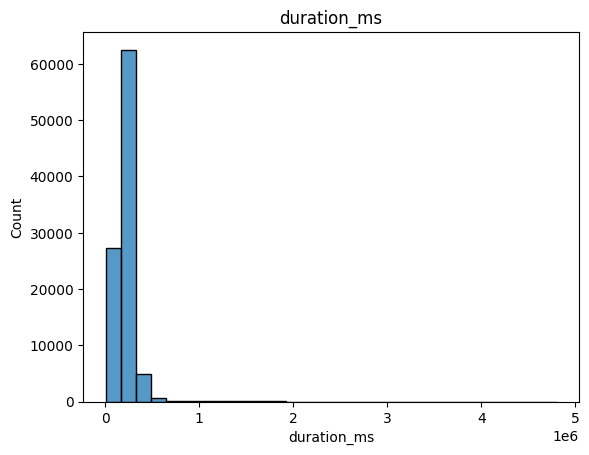

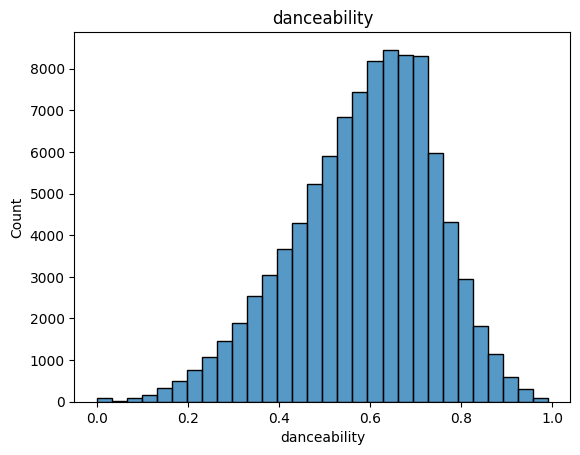

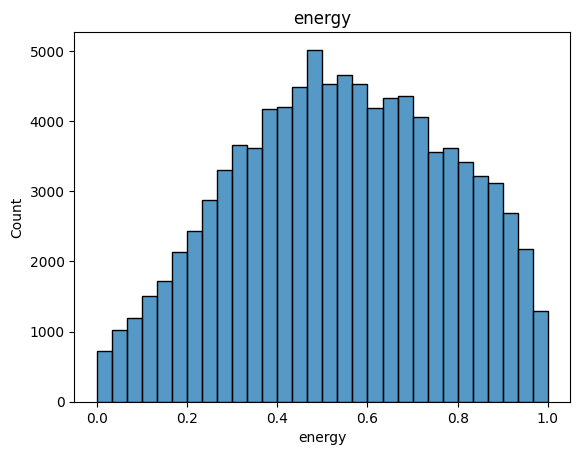

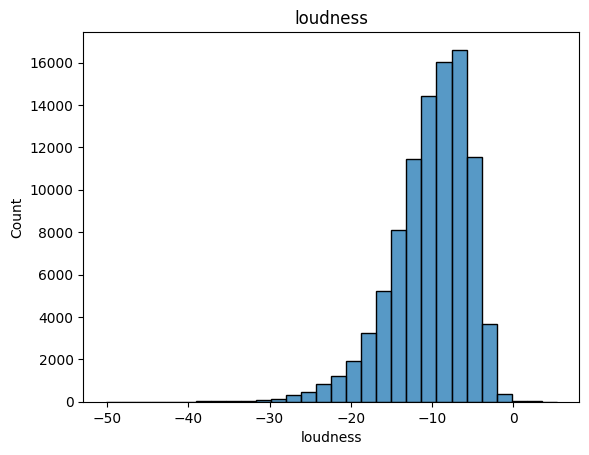

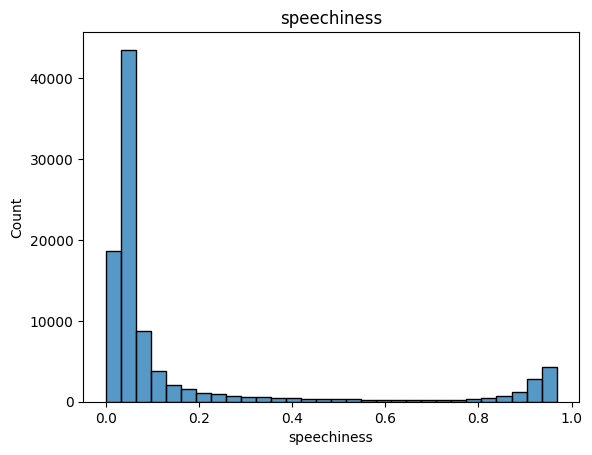

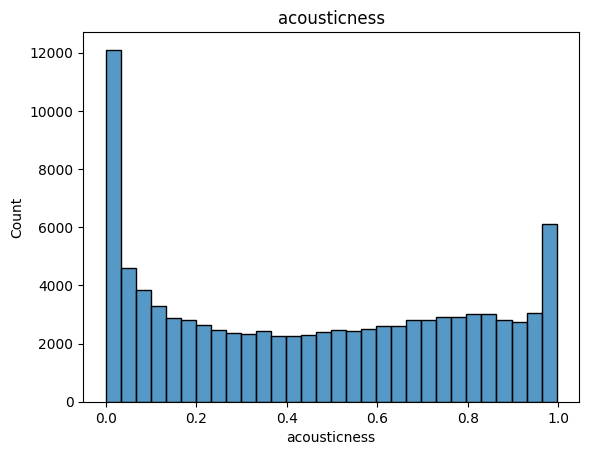

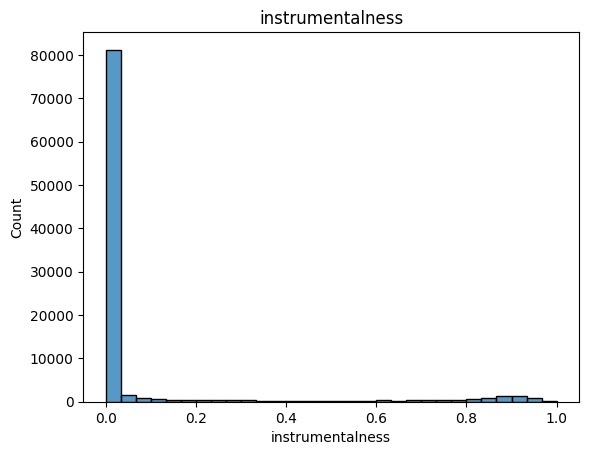

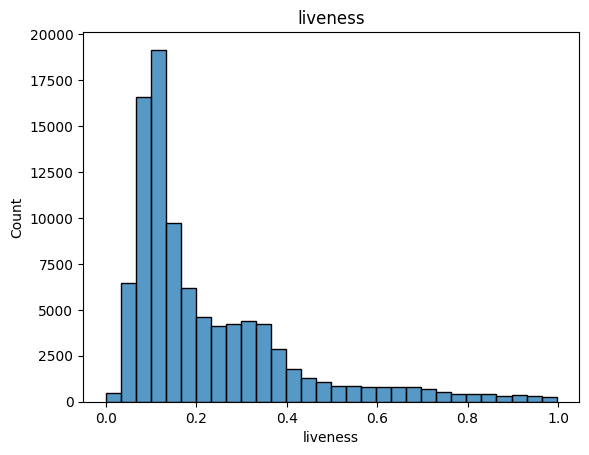

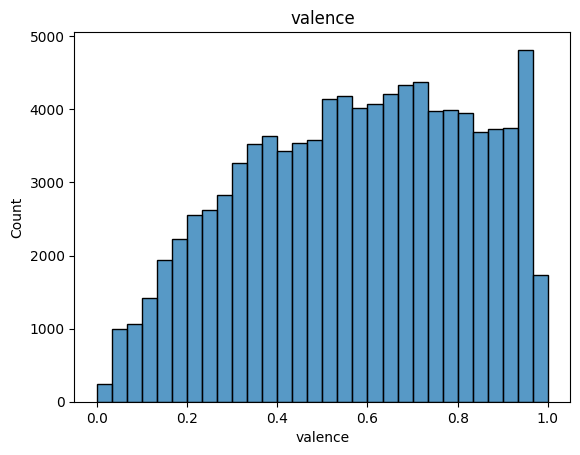

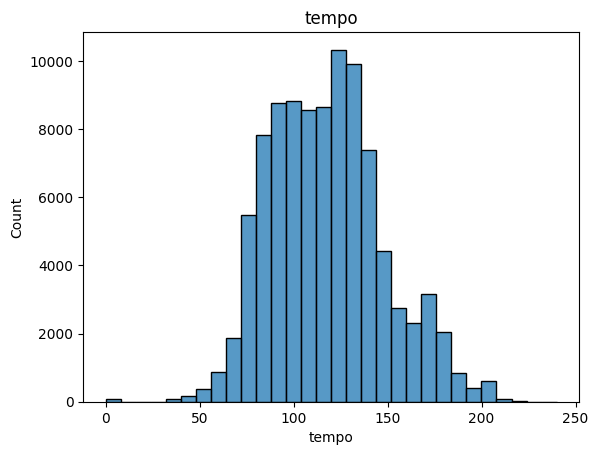

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in features:
    plt.figure()
    sns.histplot(df[col], bins=30)
    plt.title(col)
    plt.show()

In [ ]:
df[features].describe() 

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])
df_clean = pd.DataFrame(df_scaled, columns=df[features].columns)

df_clean.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-0.401735,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005
1,0.124906,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487
2,-0.003949,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003
3,-0.397437,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268
4,-0.346143,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593


In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

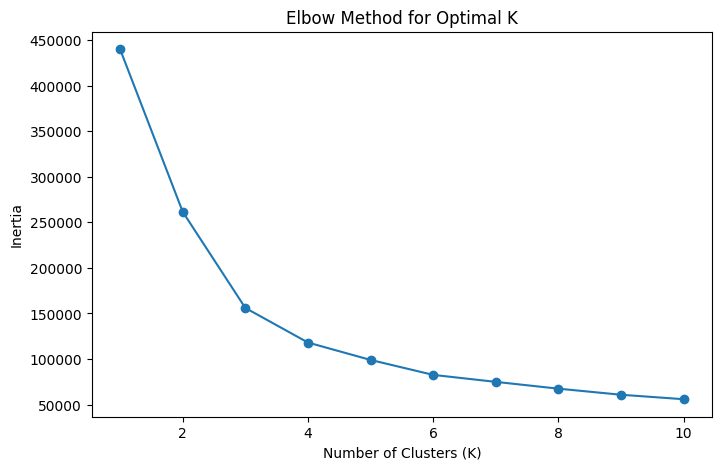

In [86]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)   # use PCA data
    
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [87]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,n_init='auto', random_state=42)
labels = kmeans.fit_predict(X_pca)

In [53]:
from sklearn.metrics import silhouette_score

silhouette_score(X_pca, labels)

0.4002137986104711

In [88]:
df['Predicted_Cluster']=labels

In [55]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_pca, labels)
db = davies_bouldin_score(X_pca, labels)
inertia = kmeans.inertia_

print("Silhouette:", sil)
print("Davies-Bouldin:", db)
print("Inertia:", inertia)

Silhouette: 0.4002137986104711
Davies-Bouldin: 0.84242900010071
Inertia: 118009.7858813931


In [89]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(df_scaled)
X_pca

array([[-1.67630407,  0.29157083],
       [-2.63996774, -0.47280334],
       [-2.53732779,  0.47446413],
       ...,
       [-4.46778363,  0.40289922],
       [-4.78999935, -0.72230182],
       [-0.42936508, -1.27917671]], shape=(95837, 2))

In [90]:
PCA_DF = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add cluster labels
PCA_DF['Predicted_Cluster'] = labels

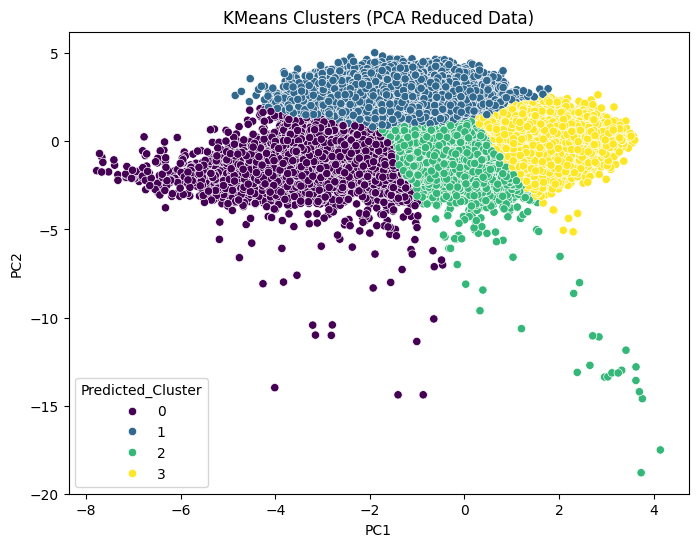

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=PCA_DF,
    x='PC1',
    y='PC2',
    hue='Predicted_Cluster',
    palette='viridis'
)

plt.title("KMeans Clusters (PCA Reduced Data)")
plt.show()

In [92]:
Profile_df=df[features]
Profile_df['Predicted_Cluster']=df['Predicted_Cluster']

C:\Users\haris\AppData\Local\Temp\ipykernel_19184\2998737692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Profile_df['Predicted_Cluster']=df['Predicted_Cluster']


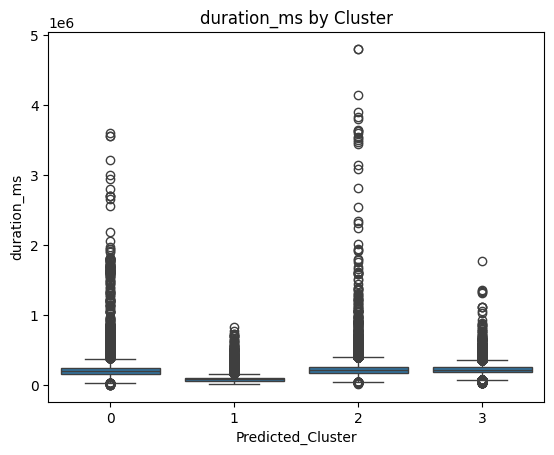

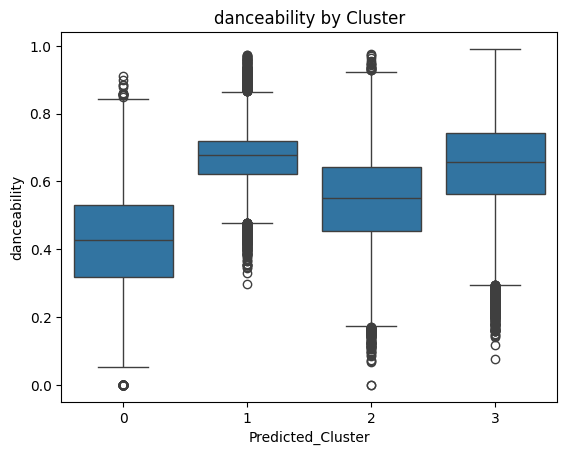

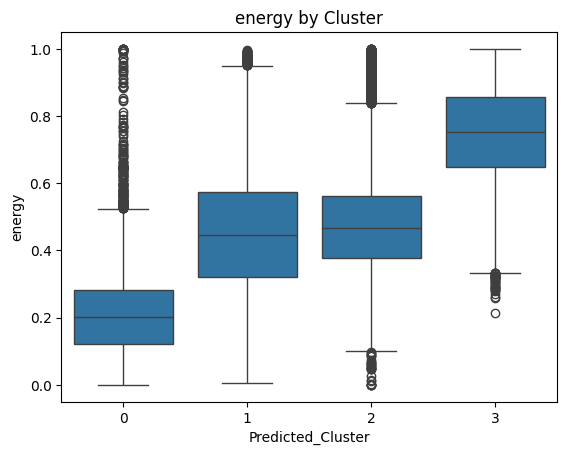

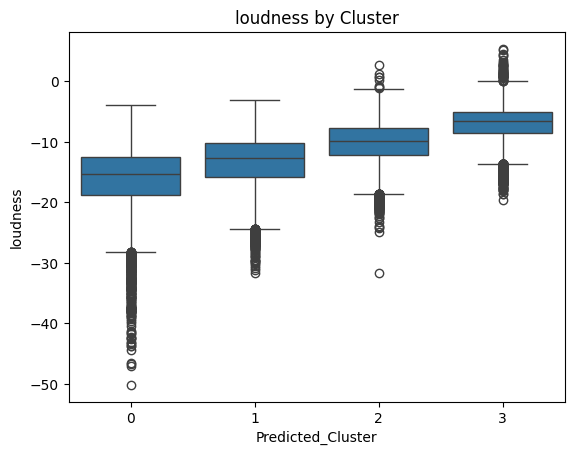

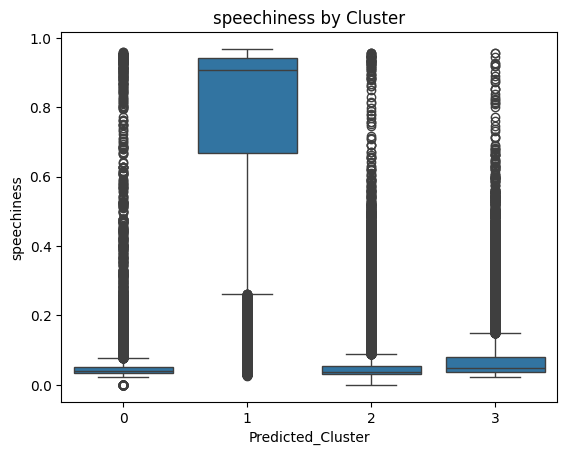

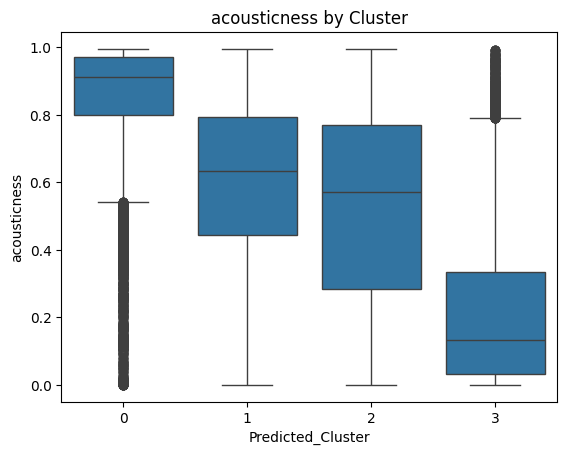

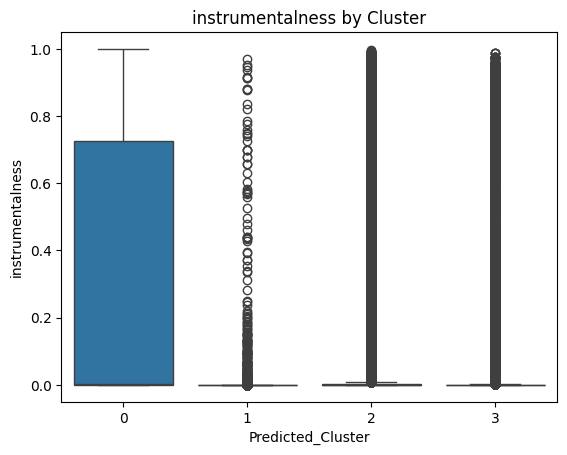

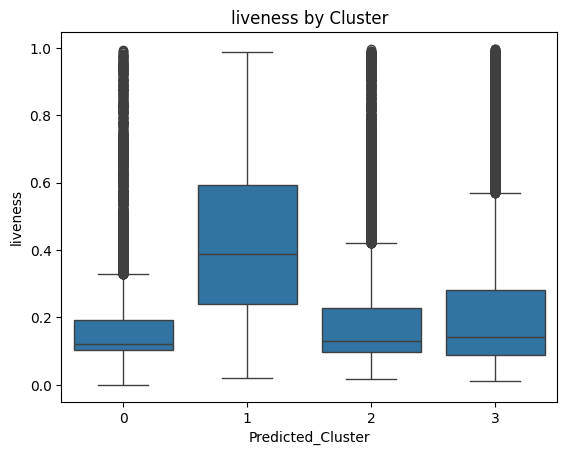

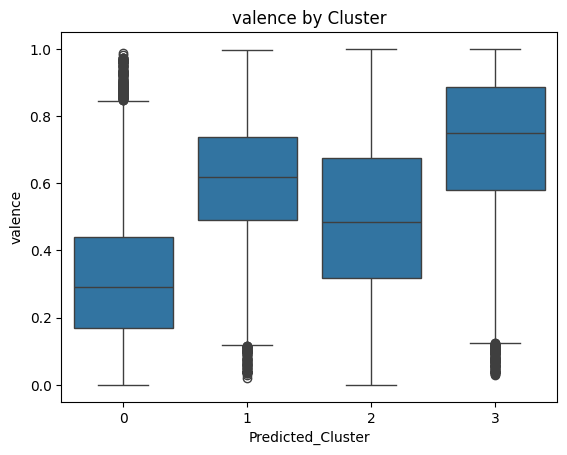

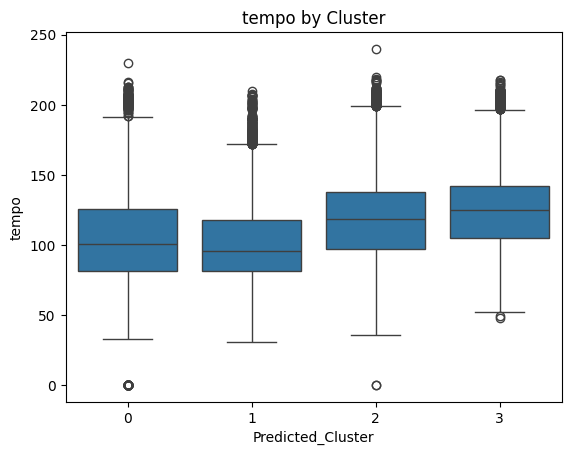

In [93]:
for col in features:
    sns.boxplot(data=Profile_df, 
                x='Predicted_Cluster', 
                y=col)
    plt.title(f"{col} by Cluster")
    plt.show()

In [94]:


cluster_profile = (df.groupby('Predicted_Cluster')[features].mean().round(3))

print(cluster_profile)


                   duration_ms  danceability  energy  loudness  speechiness  \
Predicted_Cluster                                                             
0                   227665.123         0.424   0.210   -16.110        0.065   
1                    98847.255         0.671   0.452   -13.321        0.763   
2                   233412.095         0.546   0.477   -10.067        0.060   
3                   221708.932         0.649   0.745    -6.932        0.079   

                   acousticness  instrumentalness  liveness  valence    tempo  
Predicted_Cluster                                                              
0                         0.850             0.280     0.179    0.320  105.876  
1                         0.608             0.003     0.423    0.607  100.136  
2                         0.525             0.089     0.184    0.499  119.762  
3                         0.211             0.033     0.203    0.715  126.264  


In [95]:
cluster_labels = {
    0: 'Acoustic Instrumental',
    1: 'Audio Drama & Kids Content',
    2: 'Soft Pop',
    3: 'Energetic Dance'
}

# Keep Predicted_Cluster + add Label
df['Cluster_Label'] = df['Predicted_Cluster']\
                        .map(cluster_labels)

In [97]:
print(df['Predicted_Cluster'].value_counts())

Predicted_Cluster
3    37897
2    30519
0    13726
1    13695
Name: count, dtype: int64


In [96]:
print(df['Cluster_Label'].value_counts())

Cluster_Label
Energetic Dance               37897
Soft Pop                      30519
Acoustic Instrumental         13726
Audio Drama & Kids Content    13695
Name: count, dtype: int64


In [100]:
df.columns

Index(['popularity_songs', 'duration_ms', 'explicit', 'id_artists',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'followers', 'genres', 'popularity_artists',
       'Predicted_Cluster', 'Cluster_Label'],
      dtype='object')

In [98]:
df.head()

,popularity_songs,duration_ms,explicit,id_artists,danceability,energy,key,loudness,mode,speechiness,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,Predicted_Cluster,Cluster_Label
0,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,0.563,0.184,4,-13.757,1,0.0512,...,0.000016,0.325,0.654,133.088,3,5078.0,vintage chanson,22,2,Soft Pop
1,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,0.427,0.180,10,-15.375,1,0.0670,...,0.000000,0.128,0.431,78.459,3,5078.0,vintage chanson,22,0,Acoustic Instrumental
2,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,0.511,0.206,0,-15.514,1,0.0592,...,0.000000,0.418,0.481,70.443,4,5078.0,vintage chanson,22,0,Acoustic Instrumental
3,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,0.676,0.467,9,-12.393,0,0.1650,...,0.000000,0.219,0.726,129.775,4,5078.0,vintage chanson,22,2,Soft Pop
4,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,0.650,0.298,9,-13.806,1,0.1380,...,0.000000,0.373,0.844,75.950,4,5078.0,vintage chanson,22,1,Audio Drama & Kids Content


In [102]:
top_tracks = df.groupby('Predicted_Cluster')\
               .apply(lambda x: x.nlargest(5, 'popularity_songs'))\
               [[ 'genres', 'popularity_artists',
                 'popularity_songs',
                 'Cluster_Label']]\
               .reset_index(drop=True)

print(top_tracks)

                                           genres  popularity_artists  \
0                                       dutch pop                  80   
1                                       dutch pop                  80   
2                                  indonesian pop                  70   
3               indie poptimism, modern rock, pop                  77   
4                                    indie triste                  71   
5                                          shanty                  68   
6                                     chicago rap                  91   
7                                     trap latino                  71   
8                                      uk hip hop                  68   
9                                     chicago rap                  91   
10                             australian hip hop                  90   
11                                 brooklyn drill                  92   
12                                    chicago rap  

C:\Users\haris\AppData\Local\Temp\ipykernel_19184\225552521.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'popularity_songs'))\


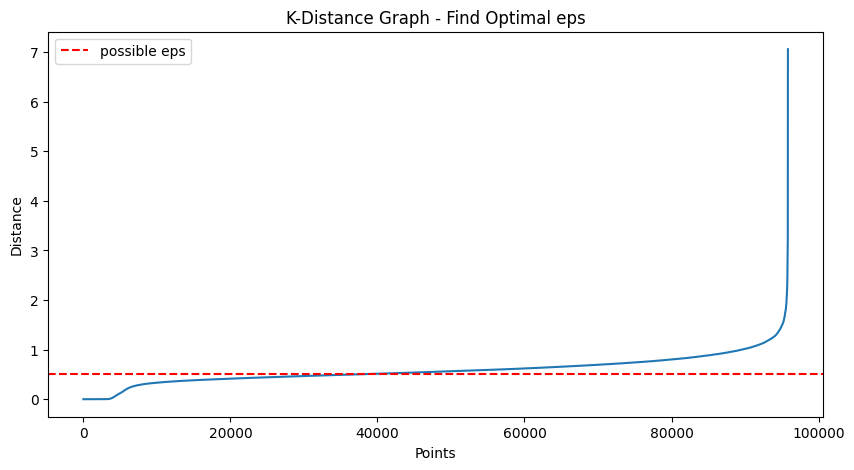

In [ ]:
'''----------------DB Scan-------------------'''



from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=2)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)

# Sort distances
distances = np.sort(distances[:, 1])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-Distance Graph - Find Optimal eps")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.axhline(y=0.5, color='red', linestyle='--', label='possible eps')
plt.legend()
plt.show()

In [105]:
from sklearn.cluster import DBSCAN
for min_s in [2, 3, 4, 5]:
    dbscan = DBSCAN(eps=0.5, min_samples=min_s)
    labels = dbscan.fit_predict(df_scaled)
    
    n_clusters = len(set(labels)) - \
                 (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    noise_pct  = n_noise / len(df) * 100
    
    print(f"eps=0.5, min_samples={min_s} → "
          f"clusters={n_clusters}, "
          f"noise={noise_pct:.1f}%")

eps=0.5, min_samples=2 → clusters=7111, noise=61.3%
eps=0.5, min_samples=3 → clusters=2094, noise=71.8%
eps=0.5, min_samples=4 → clusters=959, noise=78.7%
eps=0.5, min_samples=5 → clusters=516, noise=83.4%


In [106]:
'''-------Due to noise we go for pca in db scan--------------'''
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Reduce to 3 components first
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)

print("Variance kept:", 
      pca.explained_variance_ratio_.sum())

# Try different eps on PCA reduced data
for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_s in [5, 10, 20]:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(df_pca)
        
        n_clusters = len(set(labels)) - \
                     (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        noise_pct  = n_noise / len(df) * 100
        
        print(f"eps={eps}, min_samples={min_s} → "
              f"clusters={n_clusters}, "
              f"noise={noise_pct:.1f}%")

Variance kept: 0.5745463046564114
eps=0.3, min_samples=5 → clusters=32, noise=1.3%
eps=0.3, min_samples=10 → clusters=8, noise=2.5%
eps=0.3, min_samples=20 → clusters=6, noise=5.5%
eps=0.5, min_samples=5 → clusters=9, noise=0.3%
eps=0.5, min_samples=10 → clusters=3, noise=0.5%
eps=0.5, min_samples=20 → clusters=2, noise=0.9%
eps=0.7, min_samples=5 → clusters=1, noise=0.1%
eps=0.7, min_samples=10 → clusters=1, noise=0.2%
eps=0.7, min_samples=20 → clusters=1, noise=0.3%
eps=1.0, min_samples=5 → clusters=1, noise=0.1%
eps=1.0, min_samples=10 → clusters=1, noise=0.1%
eps=1.0, min_samples=20 → clusters=1, noise=0.1%


In [107]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# PCA first
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)

# Best parameters
dbscan = DBSCAN(eps=0.7, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_pca)

# Results
print("Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())
print(f"\nNoise points: {(df['DBSCAN_Cluster']==-1).sum()}")
print(f"Noise %: {(df['DBSCAN_Cluster']==-1).sum()/len(df)*100:.2f}%")

Cluster Distribution:
DBSCAN_Cluster
-1      107
 0    95730
Name: count, dtype: int64

Noise points: 107
Noise %: 0.11%


In [108]:
df.sort_values('Cluster_Label')\
  .to_csv('music_clustered_final.csv', index=False)